## Imports

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import os

# Add parent directory to sys.path to import custom modules
import sys
sys.path.append("..")

# Import paths for data and models from a custom configuration file
from production.config import DATA_DIR, MODELS_DIR

# Load the latest version  of the dataset from the specified data directory
df = pd.read_csv(DATA_DIR / "latest.csv")

In [2]:
# Overview of dataframe
df.head()

,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level,intensity_cat
0,56,F,165.3,53.7,Dancing,41,Low,3.3,6.6,3,7128,1.5,0
1,56,F,165.3,53.9,Swimming,28,Low,2.9,8.1,7,7925,1.8,0
2,56,F,165.3,54.2,Swimming,21,Medium,2.6,6.2,7,7557,2.7,1
3,56,F,165.3,54.4,Weight Training,99,Medium,10.7,7.2,8,11120,2.6,1
4,56,F,165.3,54.7,Swimming,100,Medium,12.7,7.1,1,5406,1.5,1


## Train–Test Split

In [3]:
# List of continuous features: STANDARD SCALER
continuous = ['age','height_cm','weight_kg','duration_minutes',
              'hours_sleep','daily_steps','calories_burned',
              'hydration_level','stress_level', ]

# List of categorial nominal features: ONE HOT ENCODE
categorical_nominal = ['gender']

# List of categorical ordinal: ORDINAL ENCODE
categorical_ordinal = ['intensity']

In [4]:
# Creating copy of df to run baseline model
df_baseline_model = df.copy()

In [5]:
# Splitting table into X: features for learning and y: target variable activity type
X = df_baseline_model.drop(['intensity_cat', 'activity_type'], axis=1)
y = df_baseline_model['activity_type']

In [6]:
# Final DataFrame for training/testing with unnecessary features removed
df_final = pd.concat([X, y], axis=1)

In [7]:
# Label encoder for target variable: activity_type
le = LabelEncoder()
y = le.fit_transform(df["activity_type"])  

In [8]:
# Shape check of target var
y

array([2, 5, 5, ..., 9, 0, 9], shape=(687699,))

In [9]:
# Checking correct columns
X.head(5)

,age,gender,height_cm,weight_kg,duration_minutes,intensity,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level
0,56,F,165.3,53.7,41,Low,3.3,6.6,3,7128,1.5
1,56,F,165.3,53.9,28,Low,2.9,8.1,7,7925,1.8
2,56,F,165.3,54.2,21,Medium,2.6,6.2,7,7557,2.7
3,56,F,165.3,54.4,99,Medium,10.7,7.2,8,11120,2.6
4,56,F,165.3,54.7,100,Medium,12.7,7.1,1,5406,1.5


In [10]:
"""
Build a full preprocessing + model pipeline.

Parameters
----------
continuous : list
    Column names for continuous numerical features that require scaling.
categorical_nominal : list
    Column names for nominal categorical features to be one-hot encoded.
categorical_ordinal : list
    Column names for ordinal categorical features to be ordinal encoded.

Returns
-------
Pipeline
    A scikit-learn Pipeline object that applies preprocessing
    and then fits a RandomForestClassifier.
"""
def build_pipeline(continuous, categorical_nominal, categorical_ordinal):

    # Build preprocessor: Columns transformer for encoding different data types
    preprocessor = ColumnTransformer(
        transformers=[
            ('nums', StandardScaler(), continuous),
            ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_nominal),
            ('ordinal', OrdinalEncoder(categories=[['Low','Medium','High']]), categorical_ordinal)
        ]
    )
    
    # Creating a training pipeling: 1. preprocess data, 2. train model 
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100))
    ])

    return pipeline

In [11]:
# Creating pipeline object to test a baseline model
pipeline = build_pipeline(continuous, categorical_nominal, categorical_ordinal)

In [12]:
# 1. Visualising preprocessing steps 
pipeline.named_steps['preprocessor']

,transformers,"[('nums', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [13]:
# 2. Model parameters
pipeline.named_steps['model']

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Baseline model

In this section, we train a **baseline model** to serve as a **benchmark** before incorporating menstrual data.
This helps us:

1. Understand initial predictive power — especially important when working with a synthetic dataset.

2. Explore feature correlations — to identify relationships that can guide future integration of menstrual variables.

3. Create a benchmark — providing a reference point to compare improvements after adding menstrual data.

visualisation of model parameter(TO BE INCLUDED): https://www.datacamp.com/tutorial/random-forests-classifier-python?dc_referrer=https%3A%2F%2Fwww.google.com%2F

In [14]:
# Splitting data into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Visualising X_train
X_train

,age,gender,height_cm,weight_kg,duration_minutes,intensity,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level
16839,45,M,171.8,115.2,24,High,8.6,6.3,1,8244,3.4
246537,56,M,173.5,114.0,120,High,63.7,6.3,3,8462,2.0
548617,21,F,172.1,76.8,73,Low,10.9,7.6,7,10198,2.4
77911,48,M,181.5,114.5,80,Medium,9.1,7.4,2,2982,2.5
331151,36,F,158.4,79.5,120,Medium,17.4,8.3,9,9515,2.7
...,...,...,...,...,...,...,...,...,...,...,...
259178,53,F,159.8,79.1,26,Medium,5.0,7.5,5,8252,3.1
365838,61,F,160.9,95.7,72,Medium,19.5,5.9,8,8167,2.1
131932,56,F,167.0,110.6,99,Medium,25.5,7.6,2,10369,2.8
671155,36,F,166.3,91.0,46,Medium,11.1,9.3,7,7453,2.7


In [16]:
# Fitting training data X and y to model
pipeline.fit(X_train, y_train)

# Making predictions on test data
y_pred = pipeline.predict(X_test)

# Comparing model output predictions with ground truth predictions
print(classification_report(y_test, y_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

     Basketball       0.68      0.65      0.67     13861
        Cycling       0.72      0.74      0.73     13826
        Dancing       0.82      0.89      0.86     13802
           HIIT       0.97      0.99      0.98     13815
        Running       0.93      0.94      0.94     13393
       Swimming       0.64      0.65      0.64     13680
         Tennis       0.60      0.57      0.58     13714
        Walking       0.99      0.98      0.99     13605
Weight Training       0.85      0.80      0.83     13930
           Yoga       0.98      0.99      0.99     13914

       accuracy                           0.82    137540
      macro avg       0.82      0.82      0.82    137540
   weighted avg       0.82      0.82      0.82    137540



In [17]:
# Extract the trained model from the pipeline
model = pipeline.named_steps['model']

In [18]:
# Importance of each feature when predicting activity type
importances = model.feature_importances_
print(importances)

[0.05918158 0.07095959 0.15146638 0.18999078 0.06265374 0.07467638
 0.24622725 0.05554158 0.04558771 0.00306276 0.00304462 0.0010509
 0.03655674]


In [19]:
# Get feature names from preprocessing pipeline for visualisation purposes
feature_names = [
  'Age', 'Height (cm)', 'Weight (kg)', 'Workout Duration (min)',
    'Sleep (hrs)', 'Daily Steps', 'Calories Burned',
    'Hydration Level', 'Stress Level',
    'Gender: F', 'Gender: M', 'Gender: Other',
    'Intensity'
]

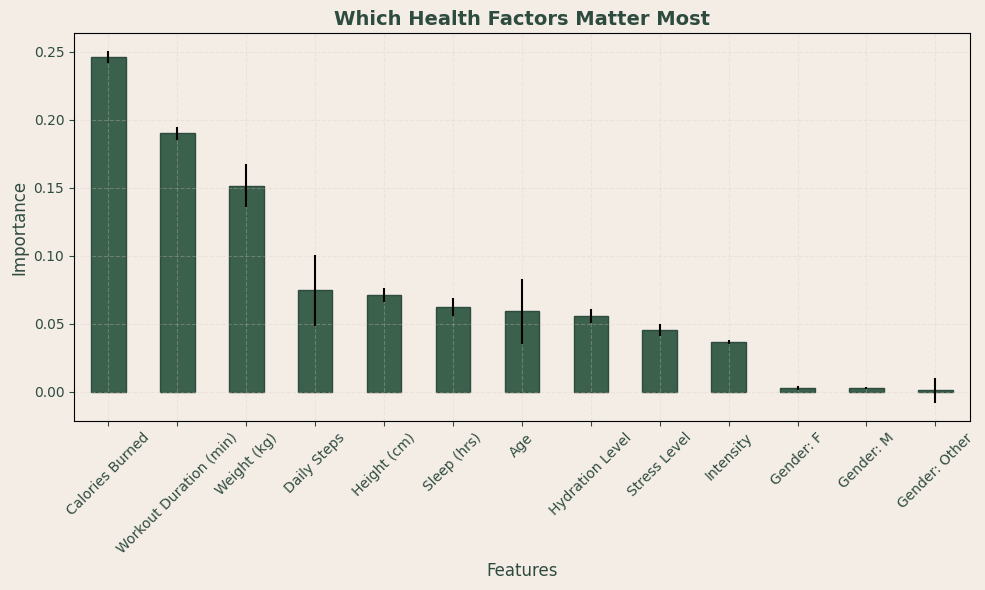

In [20]:
# Series for feature importances
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Standard deviation shows how much feature importance varies across all trees
std = np.std([est.feature_importances_ for est in model.estimators_], axis=0)

# Plot dimensions
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
forest_importances.plot.bar(
    yerr=std,
    ax=ax,
    color='#3B604C',
    edgecolor='#2E4B3F'
)

# Titles and labels
ax.set_title("Which Health Factors Matter Most", fontsize=14, fontweight='bold', color='#2E4B3F')
ax.set_ylabel("Importance", fontsize=12, color='#2E4B3F')
ax.set_xlabel("Features", fontsize=12, color='#2E4B3F')

# Style
ax.tick_params(axis='x', colors='#2E4B3F', rotation=45)
ax.tick_params(axis='y', colors='#2E4B3F')
ax.grid(color='#D8CFC4', linestyle='--', alpha=0.3)

# Background
fig.patch.set_facecolor('#F4EDE6')
ax.set_facecolor('#F4EDE6')

plt.tight_layout()
plt.show()

## Saving 

In [21]:
# Saving trained baseline model pipeline
joblib.dump(pipeline, "../models/fitted_pipeline.pkl", compress=3)

['../models/fitted_pipeline.pkl']

In [22]:
# Update dataframe to latest version
OUTPUT_PATH = Path("../data/latest.csv")   
df_final.to_csv(OUTPUT_PATH, index=False)
